In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.21.0
All imports successful!


In [2]:
base_dir = '../datasets/spiral/Spiral Drawing Images/spiral'
train_dir = os.path.join(base_dir, 'training')
test_dir = os.path.join(base_dir, 'testing')

print("Training path:", train_dir)
print("Testing path:", test_dir)
print("\nTraining classes:", os.listdir(train_dir))
print("Testing classes:", os.listdir(test_dir))

Training path: ../datasets/spiral/Spiral Drawing Images/spiral/training
Testing path: ../datasets/spiral/Spiral Drawing Images/spiral/testing

Training classes: ['healthy', 'parkinson']
Testing classes: ['healthy', 'parkinson']


In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nClass indices:", train_generator.class_indices)

Found 72 images belonging to 2 classes.
Found 30 images belonging to 2 classes.

Class indices: {'healthy': 0, 'parkinson': 1}


In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [6]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.4444 - loss: 0.8772 - val_accuracy: 0.5000 - val_loss: 0.7082
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3750 - loss: 0.7500 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5139 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4167 - loss: 0.6996 - val_accuracy: 0.5000 - val_loss: 0.6972
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5000 - loss: 0.7039 - val_accuracy: 0.5000 - val_loss: 0.7058
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5000 - loss: 0.7057 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5000 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5000 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.69

In [7]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
print("SSL fix applied!")

SSL fix applied!


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Transfer learning model ready!")

Transfer learning model ready!


In [9]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.4306 - loss: 1.0187 - val_accuracy: 0.5000 - val_loss: 0.9327
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5278 - loss: 0.7530 - val_accuracy: 0.5000 - val_loss: 0.8117
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4444 - loss: 0.7521 - val_accuracy: 0.5000 - val_loss: 0.7286
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5139 - loss: 0.7632 - val_accuracy: 0.5667 - val_loss: 0.6720
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4722 - loss: 0.7758 - val_accuracy: 0.6667 - val_loss: 0.6310
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6806 - loss: 0.6105 - val_accuracy: 0.7000 - val_loss: 0.5972
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6528 - loss: 0.5843 - val_accuracy: 0.7333 - val_loss: 0.5716
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6389 - loss: 0.5965 - val_accuracy: 0.7667 - val_loss: 0.552

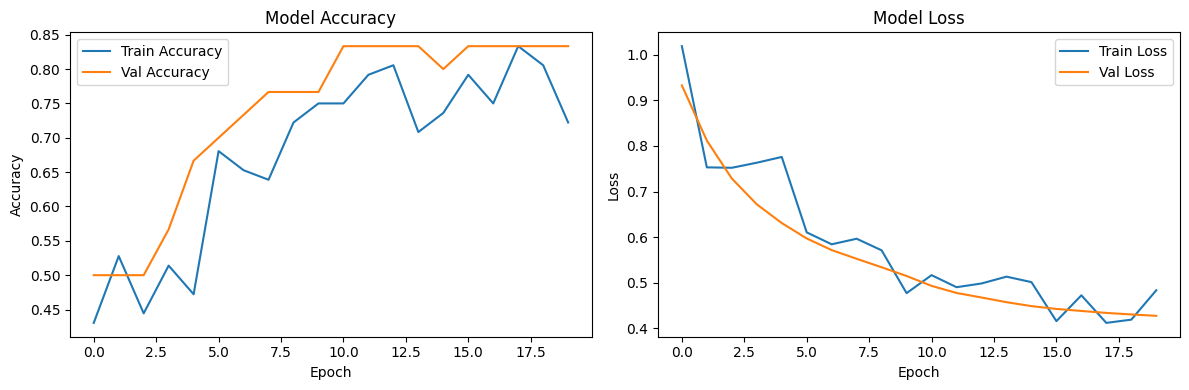

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
test_generator.reset()
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8333 - loss: 0.4275

Test Accuracy: 83.33%
Test Loss: 0.4275


In [12]:
import os
os.makedirs('../backend/models', exist_ok=True)

model.save('../backend/models/spiral_model.keras')
print("Spiral model saved successfully!")
print("Saved to: backend/models/spiral_model.keras")

Spiral model saved successfully!
Saved to: backend/models/spiral_model.keras


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Much more aggressive augmentation this time
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)

Found 72 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'healthy': 0, 'parkinson': 1}
Training samples: 72


In [14]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Rebuild transfer learning model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

new_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

new_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping prevents overfitting
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

print("Training with augmented data...")
history2 = new_model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stop],
    verbose=1
)

Training with augmented data...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.4444 - loss: 0.9417 - val_accuracy: 0.5667 - val_loss: 0.7051
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4444 - loss: 0.8387 - val_accuracy: 0.7667 - val_loss: 0.6134
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5833 - loss: 0.7738 - val_accuracy: 0.6333 - val_loss: 0.5841
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5278 - loss: 0.7542 - val_accuracy: 0.7667 - val_loss: 0.5582
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5694 - loss: 0.7496 - val_accuracy: 0.7667 - val_loss: 0.5370
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6667 - loss: 0.6063 - val_accuracy: 0.8000 - val_loss: 0.5248
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6250 - loss: 0.6345 - val_accuracy: 0.8000 - val_loss: 0.5197
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6111 - loss: 0.6422 - val_acc

In [16]:
# Evaluate final model
loss, accuracy = new_model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")

# Save the new improved model
import os
os.makedirs('../backend/models', exist_ok=True)
new_model.save('../backend/models/spiral_model.keras')
print("✅ Improved spiral model saved!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8000 - loss: 0.5248

Final Test Accuracy: 80.00%
✅ Improved spiral model saved!
